In [2]:
# %matplotlib widget
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils

In [3]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [4]:
data = pd.read_pickle("../../data/raw/FN/itr_200.bz2")
with open("umap_model.pkl", "rb") as f:
    _s, _u = pickle.load(f)  # use pretrained model (fitted to FN itr_200 run 136)
# u = umap.UMAP() # redefine model

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
l = analyse.compute_param(data, 0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


1. Fit the scaler as well as the reducer (u) (commented lines below) to a 'nice' timeseries with clear two different states.
2. Then comment out the fit lines, and use the fitting parameters to simply transform all new data (runs).
3. You should see the time segments getting nicely clustered into two states.
4. The time scale can be controlled using the chunk_size parameter. Smaller parameter value will detect states that last for shorter times. Larger values will require longer persistence within a state to be detected as distinct.

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


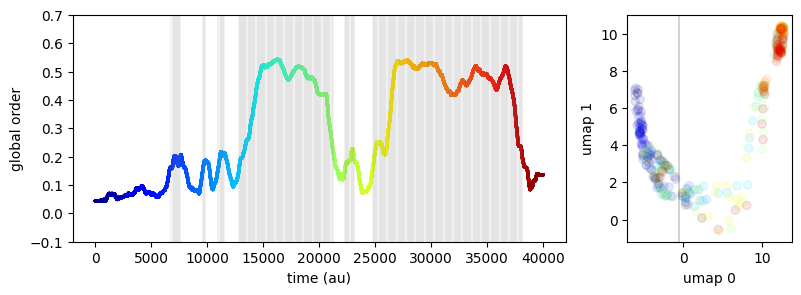

In [6]:
run = 77
_data = (
    data[run].rolling(800, center=True).mean().ffill().bfill()
)  # fit to 39, borderline 135, 136,2,77,162 interesting 193,77
cmap = "jet"  # prism or jet

f, [ax0, ax2] = plt.subplots(
    1, 2, figsize=(8, 3), tight_layout=True, width_ratios=[3, 1]
)
ax0.scatter(_data.index, _data, c=_data.index, s=2, cmap=cmap)
ax0.set_ylim(-0.1, 0.7)
ax0.set_xlabel("time (au)")
ax0.set_ylabel("global order")

chunk_size = 400
# When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
# create overlapping chunks with 75% overlap

# _s = StandardScaler().fit(chunks)
scaled_data = _s.transform(chunks)
# Train StandardScaler, Z score normalising values

# _u = u.fit(scaled_data)
embedding = _u.transform(scaled_data)
# Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary

sep = -0.6

ax2.scatter(
    embedding[:, 0], embedding[:, 1], c=range(len(chunks)), alpha=0.1, cmap=cmap
)
ax2.set_xlabel("umap 0")
ax2.set_ylabel("umap 1")
ax2.axvline(sep, c="k", lw=0.25)

l_embed = []
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    l_embed.append(l)
    ax0.axvline(l, c="gray", alpha=0.1)

In [7]:
start = []
stop = []

In [8]:
if len(l_embed) != 0:
    start = [l_embed[0]]
    stop = []
    ind = 0
    while ind < len(l_embed) - 1:

        if l_embed[ind + 1] - l_embed[ind] > 400:
            stop.append(l_embed[ind])
            start.append(l_embed[ind + 1])

        ind += 1

    # for adding start point
    if len(start) != 0:
        print(f"start {start}")
        if l_embed[-1] - start[-1] < 400:
            start.pop(-1)

    # for adding stop points if it falls
    if len(start) != 0:
        if l_embed[-1] - start[-1] > 400:
            stop.append(l_embed[-1])
            if len(start) != len(stop):
                stop.pop(-1)

    # Ignoring where GO never crosses 0.2 and length > 400
    for _start, _stop in zip(start, stop):
        val = []
        for r in range(_start, _stop, 100):
            val.append(_data[r])

        if _stop - _start <= 400 or r <= 0.2:
            stop.remove(_stop)
            start.remove(_start)

    # if there is only one transition which does not fall back, remove the stop point
    if len(stop) != 0:
        if _data[stop[-1]] >= 0.3:
            stop.pop(-1)

start [6800, 9600, 11000, 12800, 22300, 24800]


Text(0.5, 0, 'Time Steps')

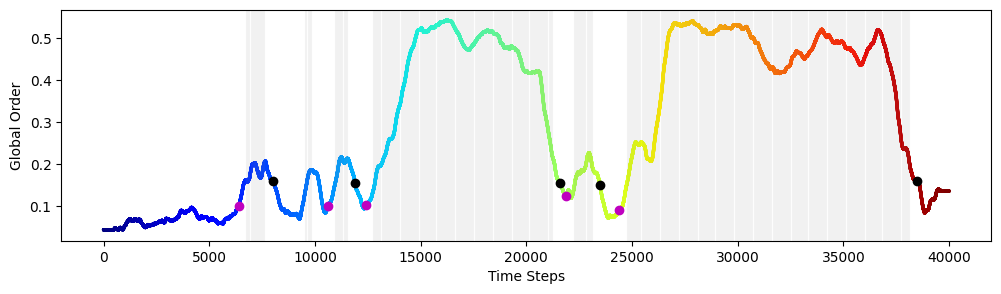

In [9]:
# 30900
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(_data.index, _data, c=_data.index, s=2, cmap=cmap)
for i in stop:
    ax.plot(i + chunk_size, _data[i + chunk_size], "ko")
for i in start:
    ax.plot(i - chunk_size, _data[i - chunk_size], "mo")
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax.axvline(l, c="gray", alpha=0.1)
ax.set_ylabel("Global Order")
ax.set_xlabel("Time Steps")

In [10]:
print(f"Number of transitions {len(start)}")

Number of transitions 5


In [11]:
start

[6800, 11000, 12800, 22300, 24800]

In [12]:
stop

[7600, 11500, 21200, 23100, 38100]

### Sync time

In [13]:
t = []
if len(start) != 0 and len(stop) != 0:
    if len(start) == len(stop) or len(start) > len(stop):
        for _start, _stop in zip(start, stop):
            time = _stop + chunk_size - (_start - 400)
            t.append(time)
    print(f"time {t}")
    sync_time = sum(t) / len(t)
    print(sync_time * 0.05)

time [1600, 1300, 9200, 1600, 14100]
278.0


In [14]:
sync_time

5560.0

In [15]:
len(embedding)

396

### First passage time

In [16]:
fpt = start[0] * 0.05
fpt

340.0

## Finding transition time 
1. Calculate slope in window
2. If slope changes to near to zero
3. Take it as end point for transition time


In [17]:
start

[6800, 11000, 12800, 22300, 24800]

In [18]:
l_embed

[6800,
 6900,
 7000,
 7100,
 7200,
 7300,
 7400,
 7500,
 7600,
 9600,
 9700,
 9800,
 11000,
 11100,
 11200,
 11300,
 11400,
 11500,
 12800,
 12900,
 13000,
 13100,
 13200,
 13300,
 13400,
 13500,
 13600,
 13700,
 13800,
 13900,
 14000,
 14100,
 14200,
 14300,
 14400,
 14500,
 14600,
 14700,
 14800,
 14900,
 15000,
 15100,
 15200,
 15300,
 15400,
 15500,
 15600,
 15700,
 15800,
 15900,
 16000,
 16100,
 16200,
 16300,
 16400,
 16500,
 16600,
 16700,
 16800,
 16900,
 17000,
 17100,
 17200,
 17300,
 17400,
 17500,
 17600,
 17700,
 17800,
 17900,
 18000,
 18100,
 18200,
 18300,
 18400,
 18500,
 18600,
 18700,
 18800,
 18900,
 19000,
 19100,
 19200,
 19300,
 19400,
 19500,
 19600,
 19700,
 19800,
 19900,
 20000,
 20100,
 20200,
 20300,
 20400,
 20500,
 20600,
 20700,
 20800,
 20900,
 21000,
 21100,
 21200,
 22300,
 22400,
 22500,
 22600,
 22700,
 22800,
 22900,
 23000,
 23100,
 24800,
 24900,
 25000,
 25100,
 25200,
 25300,
 25400,
 25500,
 25600,
 25700,
 25800,
 25900,
 26000,
 26100,
 262

In [21]:
window_size = 100


# Define a function to calculate slope for a given window
def calculate_slope(window):
    if len(window) < 2:  # Need at least two points to calculate slope
        return np.nan
    x = np.arange(0, len(window), 1)
    y = window.values
    # Using numpy.polyfit for linear regression to get slope
    slope, intercept = np.polyfit(x, y, 1)
    return slope


# Apply the slope calculation over a rolling window
# rolling_slopes = _data[l_embed].rolling(window=window_size).apply(calculate_slope, raw=False)
t_time = []
for k in start:
    rolling_slopes = (
        _data[k:].rolling(window=window_size).apply(calculate_slope, raw=False)
    )
    for i in rolling_slopes.index:
        if rolling_slopes[i] < 0:
            print(i)
            c = i - 1
            t_time.append(c)
            break


print(t_time)

7196
11300
13619
22517
25239
[7195, 11299, 13618, 22516, 25238]


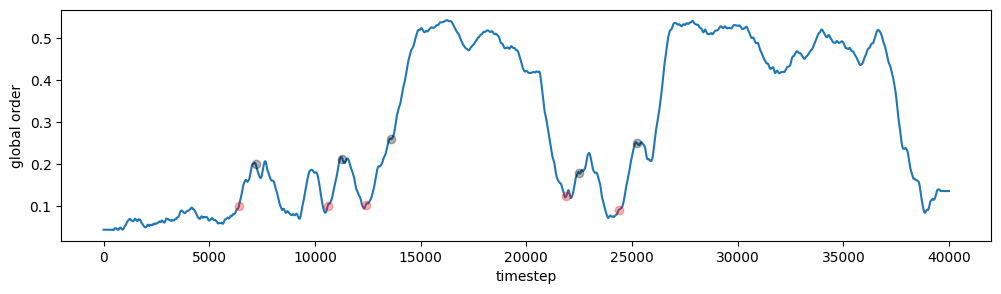

In [24]:
f, ax = plt.subplots(figsize=(12, 3))
ax.plot(_data.index, _data)

# plot start points
for y in start:
    ax.plot(y - 400, _data[y - 400], "ro", alpha=0.3)
# plot end points
for x in t_time:
    ax.plot(x, _data[x], "ko", alpha=0.3)
ax.set_xlabel("timestep")
ax.set_ylabel("global order")
plt.savefig("tt.png")

In [23]:
def compute_transition_time: 

    t=[]
    if len(start)>0:
        for _init,_end in zip(start,t_time):
            time=_end-(_init-400)
            t.append(time)
    
    transition_time=[item*0.05 for item in t]
    
    return transition_time       

SyntaxError: invalid syntax (2760242612.py, line 1)

In [441]:
[item * 0.05 for item in t]

[81.0]

In [319]:
start

[10400]

In [322]:
t_time

[11494]

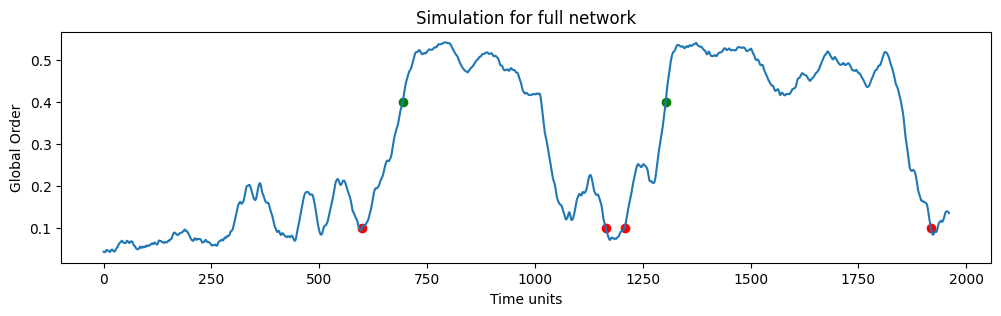

In [252]:
plt.figure(figsize=(12, 3))
analyse.plot_global_synchrony(data[run], 0.05)

In [253]:
# save trained model
# with open('umap_model.pkl', 'wb') as f:
#     pickle.dump((_s, _u), f)